# Data Understanding & EDA
Phân tích dataset **sau khi bổ sung data** từ AIVIVN 2019 + minhtoan.
Đọc trực tiếp từ `data/processed/` (đã merge sẵn).

In [7]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
os.makedirs('../reports', exist_ok=True)
print('Setup done')

Setup done


## 1. Load Dataset

In [8]:
# Load 3 splits đã merge (schema mới: 'review', 'label', 'domain')
train_df = pd.read_csv('../data/processed/train_split.csv')
val_df   = pd.read_csv('../data/processed/val_split.csv')
test_df  = pd.read_csv('../data/processed/test_split_from_train.csv')

# Load full dataset có domain tag (nếu có)
full_path = '../data/raw/vsa_general_sentiment_full.csv'
if os.path.exists(full_path):
    full_df = pd.read_csv(full_path)
    has_domain = 'domain' in full_df.columns
else:
    full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
    has_domain = False

print('=== Dataset Overview ===')
print(f'Train:      {len(train_df):>7,} rows')
print(f'Validation: {len(val_df):>7,} rows')
print(f'Test:       {len(test_df):>7,} rows')
print(f'Total:      {len(train_df)+len(val_df)+len(test_df):>7,} rows')
print(f'\nColumns: {train_df.columns.tolist()}')
print('\nSample:')
display(train_df.head(3))

=== Dataset Overview ===
Train:       20,971 rows
Validation:   2,621 rows
Test:         2,622 rows
Total:       26,214 rows

Columns: ['review', 'label']

Sample:


,review,label
0,Dẫn bạn gái đi ăn mà nó cứ khưn ngon lại còn b...,1
1,Cũng hay ăn ở đây mà giờ mới biết quán có trên...,1
2,Sài thấy ổn định nghe gọi tốt chưa biết vài th...,1


## 2. Data Quality Check

In [9]:
print('=== Null values ===')
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    nulls = df.isnull().sum().sum()
    dups  = df.duplicated(subset=['review']).sum()
    print(f'{name:6s}: nulls={nulls}, duplicates={dups}')

print('\n=== Label distribution ===')
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    vc  = df['label'].value_counts().sort_index()
    pos = vc.get(1, 0)
    neg = vc.get(0, 0)
    total = pos + neg
    print(f'{name:6s}: pos={pos:,} ({pos/total*100:.1f}%)  neg={neg:,} ({neg/total*100:.1f}%)  total={total:,}')

=== Null values ===
train : nulls=0, duplicates=0
val   : nulls=0, duplicates=0
test  : nulls=0, duplicates=0

=== Label distribution ===
train : pos=13,979 (66.7%)  neg=6,992 (33.3%)  total=20,971
val   : pos=1,747 (66.7%)  neg=874 (33.3%)  total=2,621
test  : pos=1,748 (66.7%)  neg=874 (33.3%)  total=2,622


## 3. Class Distribution

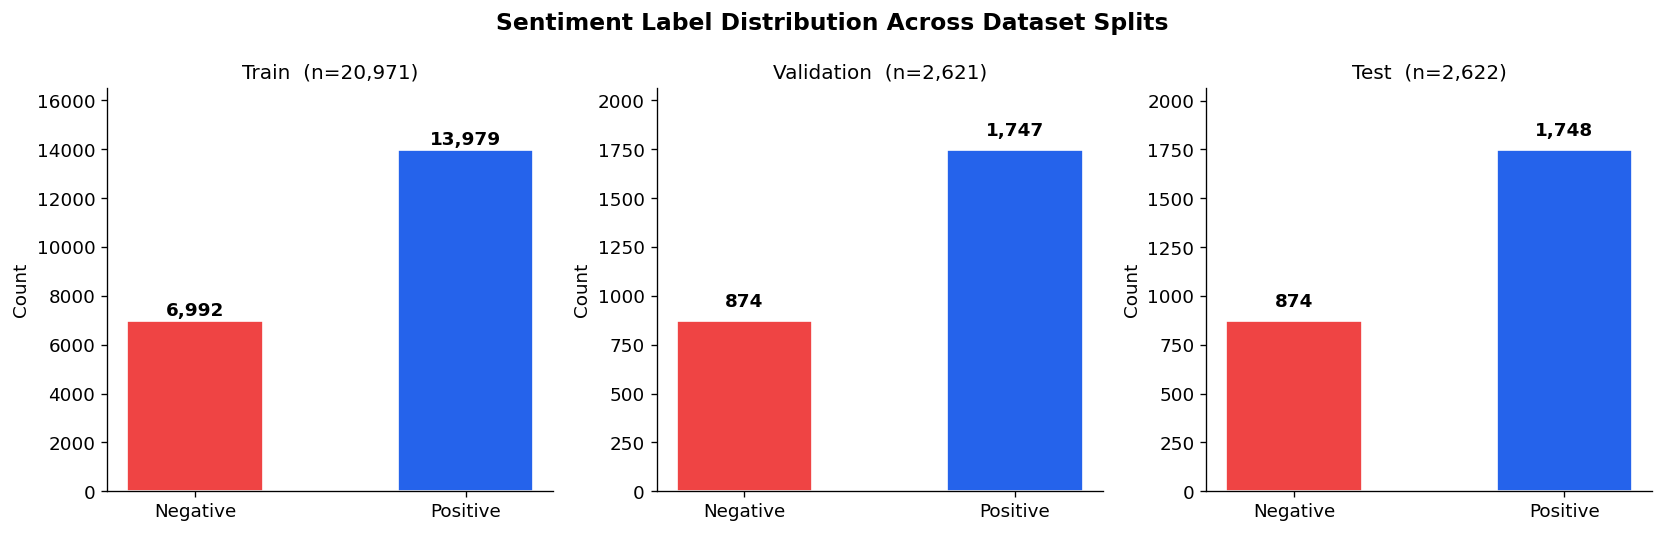

Saved: reports/eda_class_distribution.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('Sentiment Label Distribution Across Dataset Splits', fontsize=14, fontweight='bold')

colors = {'Positive': '#2563EB', 'Negative': '#EF4444'}

for ax, (name, df) in zip(axes, [('Train', train_df), ('Validation', val_df), ('Test', test_df)]):
    counts = df['label'].value_counts().sort_index()
    labels_plot = ['Negative', 'Positive']
    vals = [counts.get(0, 0), counts.get(1, 0)]
    bars = ax.bar(labels_plot, vals, color=[colors['Negative'], colors['Positive']], width=0.5, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_title(f'{name}  (n={sum(vals):,})', fontsize=12)
    ax.set_ylabel('Count')
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylim(0, max(vals)*1.18)

plt.tight_layout()
plt.savefig('../reports/eda_class_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: reports/eda_class_distribution.png')

## 4. Domain Composition (Augmented Data)

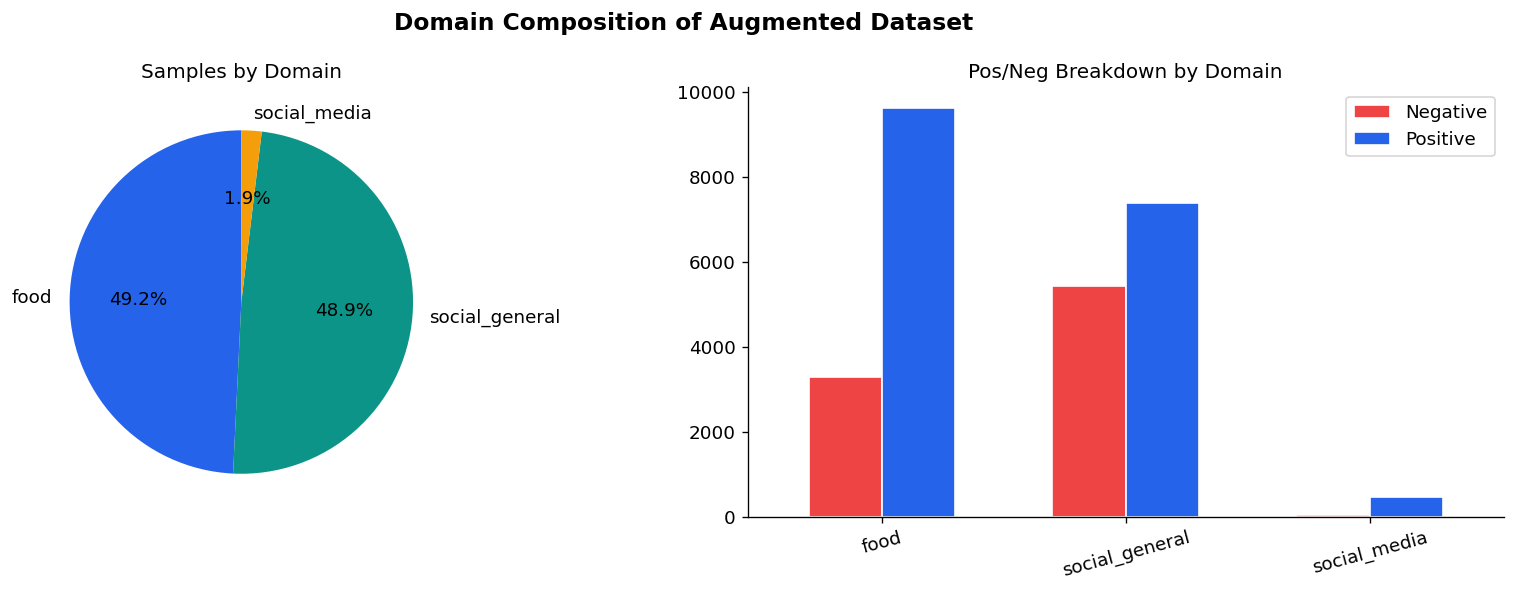

Saved: reports/eda_domain_distribution.png

=== Domain stats ===


,count,pos,neg,pos_pct
domain,,,,
food,12906,9624,3282,74.6
social_general,12809,7381,5428,57.6
social_media,499,469,30,94.0


In [11]:
if has_domain:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Domain Composition of Augmented Dataset', fontsize=14, fontweight='bold')

    # Pie chart
    domain_counts = full_df['domain'].value_counts()
    palette = ['#2563EB', '#0D9488', '#F59E0B', '#8B5CF6']
    axes[0].pie(domain_counts.values, labels=domain_counts.index,
                autopct='%1.1f%%', colors=palette[:len(domain_counts)],
                startangle=90, textprops={'fontsize':11})
    axes[0].set_title('Samples by Domain', fontsize=12)

    # Stacked bar
    domain_label = full_df.groupby(['domain','label']).size().unstack(fill_value=0)
    domain_label.columns = ['Negative','Positive']
    domain_label.plot(kind='bar', ax=axes[1], color=['#EF4444','#2563EB'],
                      edgecolor='white', width=0.6)
    axes[1].set_title('Pos/Neg Breakdown by Domain', fontsize=12)
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].spines[['top','right']].set_visible(False)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('../reports/eda_domain_distribution.png', bbox_inches='tight')
    plt.show()
    print('Saved: reports/eda_domain_distribution.png')

    print('\n=== Domain stats ===')
    stats = full_df.groupby('domain').agg(
        count=('review','count'),
        pos=('label','sum')
    )
    stats['neg']     = stats['count'] - stats['pos']
    stats['pos_pct'] = (stats['pos']/stats['count']*100).round(1)
    display(stats)
else:
    print('Không có cột domain — bỏ qua cell này.')
    print('Hãy chạy notebook merge_data_augmentation.ipynb trước để có full_df với domain tag.')

## 5. Review Length Analysis

In [12]:
# Tính độ dài trên toàn bộ dataset
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
all_df['length'] = all_df['review'].apply(lambda x: len(str(x).split()))

print('=== Review Length Statistics ===')
print(f'Mean:   {all_df["length"].mean():.1f} words')
print(f'Median: {all_df["length"].median():.1f} words')
print(f'Min:    {all_df["length"].min()} words')
print(f'Max:    {all_df["length"].max()} words')
print(f'Std:    {all_df["length"].std():.1f} words')
print()

# Phân tích theo label
print('=== Length by sentiment ===')
display(all_df.groupby('label')['length'].describe().round(1))

# Phần trăm nằm trong 128 tokens
within_128 = (all_df['length'] <= 128).mean() * 100
print(f'\n% reviews ≤ 128 words: {within_128:.1f}% — max_length=128 phù hợp')

=== Review Length Statistics ===
Mean:   63.6 words
Median: 29.0 words
Min:    1 words
Max:    1700 words
Std:    118.6 words

=== Length by sentiment ===


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,8740.0,45.6,59.6,1.0,13.0,25.0,54.0,907.0
1,17474.0,72.5,138.1,1.0,14.0,32.0,87.0,1700.0



% reviews ≤ 128 words: 88.8% — max_length=128 phù hợp


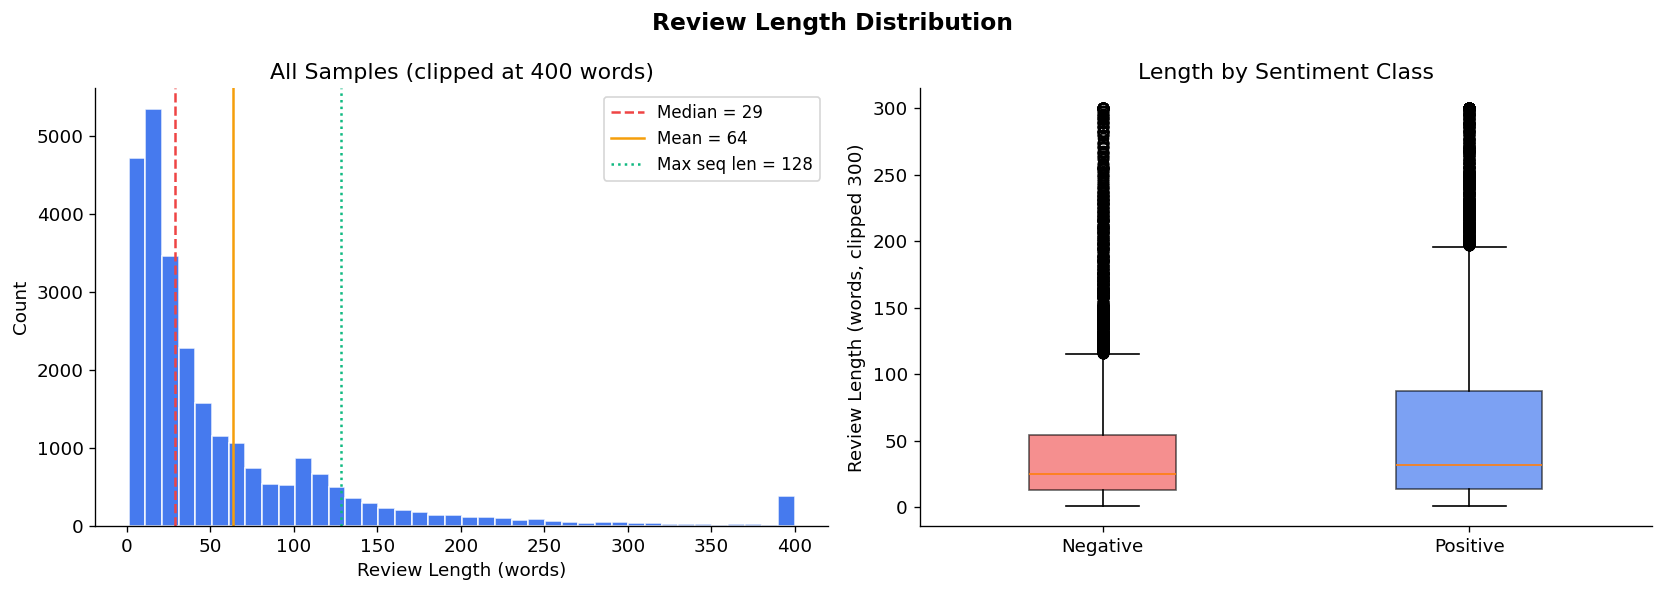

Saved: reports/eda_length_distribution.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Review Length Distribution', fontsize=14, fontweight='bold')

# Histogram toàn bộ
ax = axes[0]
ax.hist(all_df['length'].clip(upper=400), bins=40, color='#2563EB', edgecolor='white', alpha=0.85)
ax.axvline(all_df['length'].median(), color='#EF4444', linestyle='--', linewidth=1.5, label=f'Median = {all_df["length"].median():.0f}')
ax.axvline(all_df['length'].mean(),   color='#F59E0B', linestyle='-',  linewidth=1.5, label=f'Mean = {all_df["length"].mean():.0f}')
ax.axvline(128, color='#10B981', linestyle=':', linewidth=1.5, label='Max seq len = 128')
ax.set_xlabel('Review Length (words)')
ax.set_ylabel('Count')
ax.set_title('All Samples (clipped at 400 words)')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

# Boxplot pos vs neg
ax2 = axes[1]
data_pos = all_df[all_df['label']==1]['length'].clip(upper=300)
data_neg = all_df[all_df['label']==0]['length'].clip(upper=300)
bp = ax2.boxplot([data_neg, data_pos], labels=['Negative','Positive'],
                  patch_artist=True, widths=0.4)
bp['boxes'][0].set_facecolor('#EF4444'); bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#2563EB'); bp['boxes'][1].set_alpha(0.6)
ax2.set_ylabel('Review Length (words, clipped 300)')
ax2.set_title('Length by Sentiment Class')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/eda_length_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: reports/eda_length_distribution.png')

## 6. Before vs After Augmentation

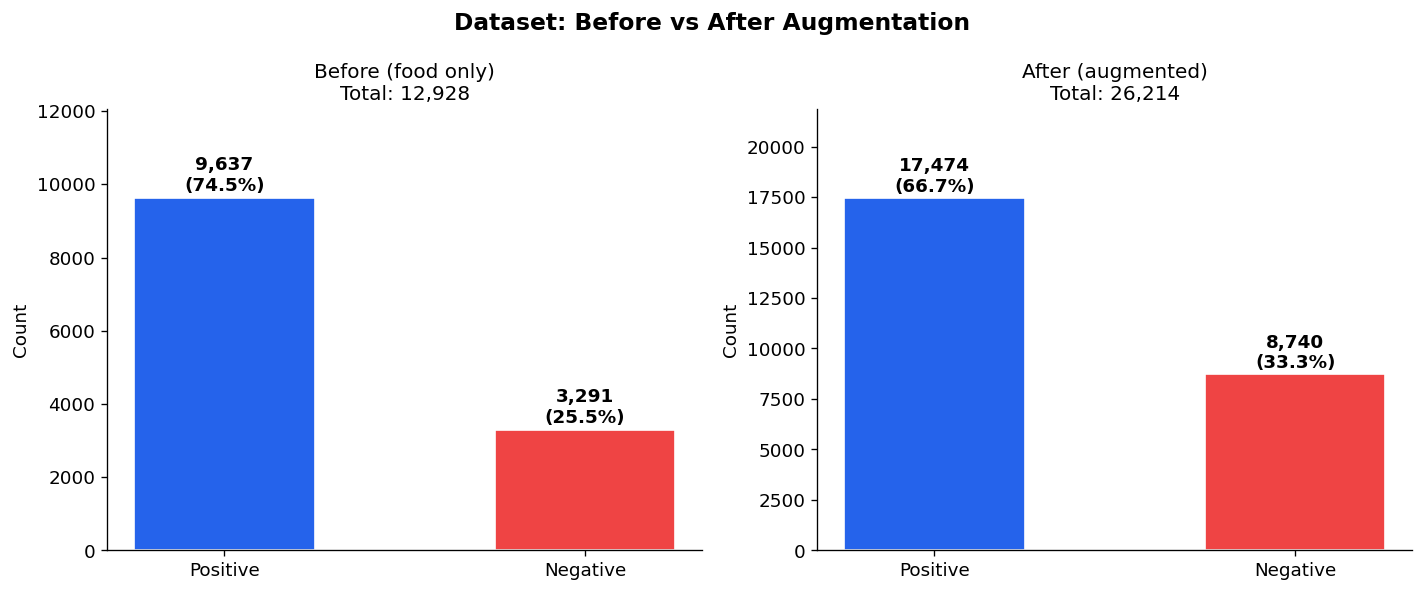

Saved: reports/eda_before_after_augmentation.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Dataset: Before vs After Augmentation', fontsize=14, fontweight='bold')

# BEFORE: food only
before = {'Positive': 9637, 'Negative': 3291}   # từ paper gốc
after  = {'Positive': sum(all_df['label']==1), 'Negative': sum(all_df['label']==0)}

for ax, (title, data) in zip(axes, [('Before (food only)', before), ('After (augmented)', after)]):
    colors_b = ['#2563EB', '#EF4444']
    bars = ax.bar(data.keys(), data.values(), color=colors_b, width=0.5, edgecolor='white')
    total = sum(data.values())
    for bar, (lbl, val) in zip(bars, data.items()):
        pct = val/total*100
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+80,
                f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(f'{title}\nTotal: {total:,}', fontsize=12)
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(data.values())*1.25)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/eda_before_after_augmentation.png', bbox_inches='tight')
plt.show()
print('Saved: reports/eda_before_after_augmentation.png')

## 7. Top Words by Sentiment

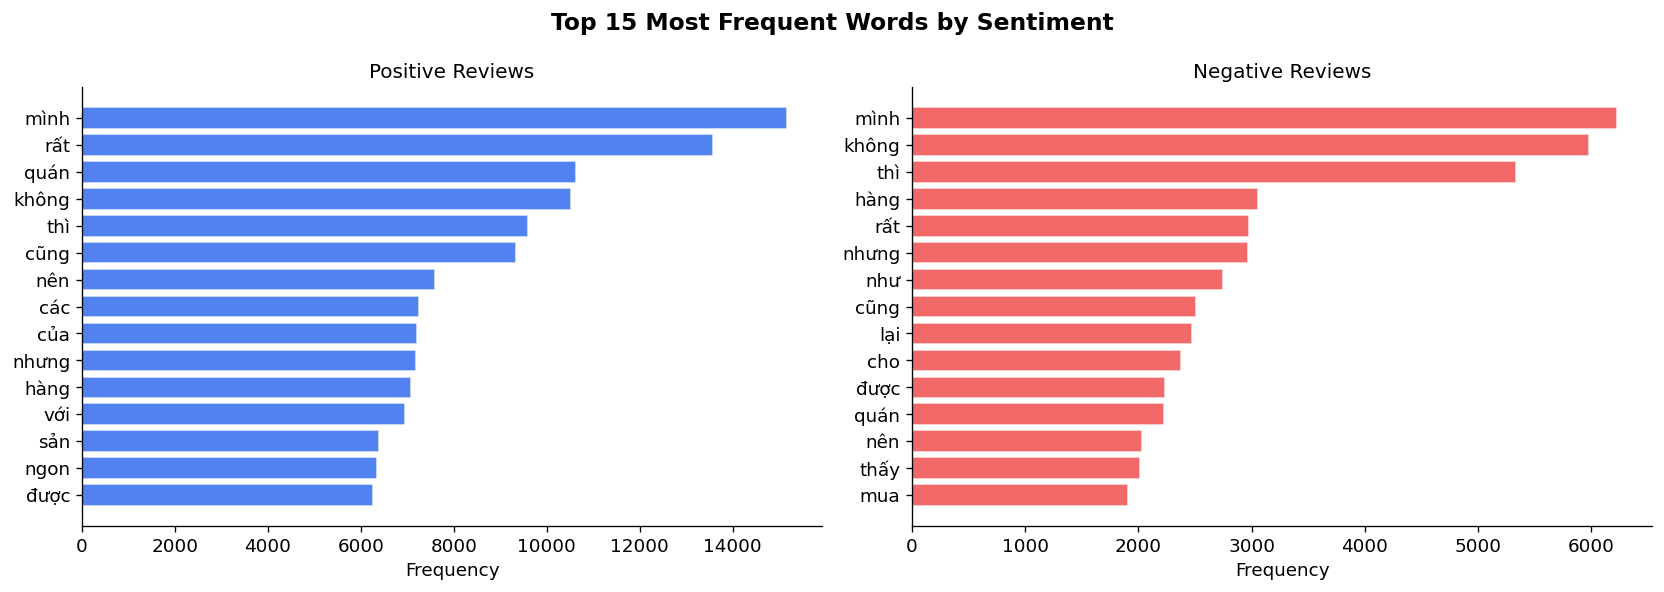

Saved: reports/eda_top_words.png


In [15]:
from collections import Counter

def get_top_words(df, label, n=20):
    texts = df[df['label']==label]['review'].str.lower().str.split()
    words = [w for tokens in texts for w in tokens if len(w) > 2]
    return Counter(words).most_common(n)

top_pos = get_top_words(all_df, 1, 15)
top_neg = get_top_words(all_df, 0, 15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Top 15 Most Frequent Words by Sentiment', fontsize=14, fontweight='bold')

for ax, (top, title, color) in zip(axes, [
    (top_pos, 'Positive Reviews', '#2563EB'),
    (top_neg, 'Negative Reviews', '#EF4444')
]):
    words_list = [w for w,_ in top]
    counts     = [c for _,c in top]
    ax.barh(words_list[::-1], counts[::-1], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Frequency')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/eda_top_words.png', bbox_inches='tight')
plt.show()
print('Saved: reports/eda_top_words.png')

## 8. Summary

In [16]:
print('='*55)
print('EDA SUMMARY — Augmented Multi-domain Dataset')
print('='*55)
print(f'Total samples:    {len(all_df):,}')
print(f'Positive (1):     {sum(all_df["label"]==1):,}  ({sum(all_df["label"]==1)/len(all_df)*100:.1f}%)')
print(f'Negative (0):     {sum(all_df["label"]==0):,}  ({sum(all_df["label"]==0)/len(all_df)*100:.1f}%)')
print(f'Pos/Neg ratio:    {sum(all_df["label"]==1)/sum(all_df["label"]==0):.2f}:1')
print(f'Mean length:      {all_df["length"].mean():.1f} words')
print(f'Median length:    {all_df["length"].median():.0f} words')
print(f'% ≤ 128 words:    {(all_df["length"]<=128).mean()*100:.1f}%')
print()
print('Reports saved:')
for f in ['eda_class_distribution.png','eda_domain_distribution.png',
          'eda_length_distribution.png','eda_before_after_augmentation.png','eda_top_words.png']:
    exists = os.path.exists(f'../reports/{f}')
    print(f'  ../reports/{f}  {"✓" if exists else "(not yet)"}')

EDA SUMMARY — Augmented Multi-domain Dataset
Total samples:    26,214
Positive (1):     17,474  (66.7%)
Negative (0):     8,740  (33.3%)
Pos/Neg ratio:    2.00:1
Mean length:      63.6 words
Median length:    29 words
% ≤ 128 words:    88.8%

Reports saved:
  ../reports/eda_class_distribution.png  ✓
  ../reports/eda_domain_distribution.png  ✓
  ../reports/eda_length_distribution.png  ✓
  ../reports/eda_before_after_augmentation.png  ✓
  ../reports/eda_top_words.png  ✓
